# EDA REHAB24-6

6 esercizi, keypoint 2D con ID soggetto e etichetta corretto/scorretto per ripetizione. Prima di fidarsi dei risultati della nested CV (`notebooks/07_experiments_analysis.ipynb`), questa e' l'esplorazione che risponde a: che aspetto ha il dato, la mappa dei giunti e' giusta, il segnale si vede gia' a occhio, e su quali feature/esercizi e' piu forte.

In [1]:
import re
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, "../src")
from rehab24_annotations import is_mocap_erroneous, subject_id_for

pd.set_option("display.width", 160)
plt.rcParams["figure.facecolor"] = "white"

BASE = Path("../data/raw/rehab24")
FILENAME_RE = re.compile(r"^(PM_\w+)_c(\d+)_(.+)-rep(\d+)-(\d+)\.npy$")
EXERCISES = ["Ex1", "Ex2", "Ex3", "Ex4", "Ex5", "Ex6"]
EXERCISE_LABELS = {
    "Ex1": "Arm abduction", "Ex2": "Arm VW", "Ex3": "Push-ups",
    "Ex4": "Leg abduction", "Ex5": "Leg lunge", "Ex6": "Squats",
}
JOINT_NAMES = ["Hips","Spine","Spine1","Neck","Head","Head_end","LeftShoulder","LeftArm",
    "LeftForeArm","LeftHand","LeftHand_end","RightShoulder","RightArm","RightForeArm",
    "RightHand","RightHand_end","LeftUpLeg","LeftLeg","LeftFoot","LeftToeBase","LeftToeBase_end",
    "RightUpLeg","RightLeg","RightFoot","RightToeBase","RightToeBase_end"]
BONES = [(0,1),(1,2),(2,3),(3,4),(4,5), (2,6),(6,7),(7,8),(8,9),(9,10),
         (2,11),(11,12),(12,13),(13,14),(14,15), (0,16),(16,17),(17,18),(18,19),(19,20),
         (0,21),(21,22),(22,23),(23,24),(24,25)]

def angle_series(arr, a, b, c):
    pa, pb, pc = arr[:, a], arr[:, b], arr[:, c]
    ba, bc = pa - pb, pc - pb
    cos = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-9)
    return np.degrees(np.arccos(np.clip(cos, -1.0, 1.0)))

print(f"{len(JOINT_NAMES)} giunti, {len(BONES)} ossa, {len(EXERCISES)} esercizi")

26 giunti, 25 ossa, 6 esercizi


## 1. Quanti soggetti, ripetizioni, corrette/scorrette, quanto durano

In [2]:
rows = []
for ex in EXERCISES:
    ex_dir = BASE / f"{ex}-segmented"
    for f in sorted(ex_dir.iterdir()):
        if f.suffix != ".npy":
            continue
        m = FILENAME_RE.match(f.name)
        if not m:
            continue
        if is_mocap_erroneous(f.name):
            continue
        _, cam, variant, rep, label = m.groups()
        arr = np.load(f)
        rows.append({"exercise": ex, "subject": subject_id_for(f.name), "rep": int(rep),
                      "correct": int(label), "n_frames": arr.shape[0], "file": f.name})

meta = pd.DataFrame(rows)
summary = meta.groupby("exercise").agg(
    soggetti=("subject", "nunique"), ripetizioni=("rep", "count"),
    corrette=("correct", "sum"), frame_min=("n_frames", "min"),
    frame_medio=("n_frames", "mean"), frame_max=("n_frames", "max"))
summary["scorrette"] = summary["ripetizioni"] - summary["corrette"]
summary["nome"] = [EXERCISE_LABELS[e] for e in summary.index]
print(summary[["nome", "soggetti", "ripetizioni", "corrette", "scorrette",
               "frame_min", "frame_medio", "frame_max"]].to_string(float_format="%.0f"))

                   nome  soggetti  ripetizioni  corrette  scorrette  frame_min  frame_medio  frame_max
exercise                                                                                              
Ex1       Arm abduction         8           88        47         41         83          159        316
Ex2              Arm VW         9          109        48         61         90          173        585
Ex3            Push-ups         9           96        46         50         58          113        241
Ex4       Leg abduction         9          116        63         53         36           89        141
Ex5           Leg lunge         8           88        39         49         41          102        166
Ex6              Squats         9           98        72         26         65          100        155


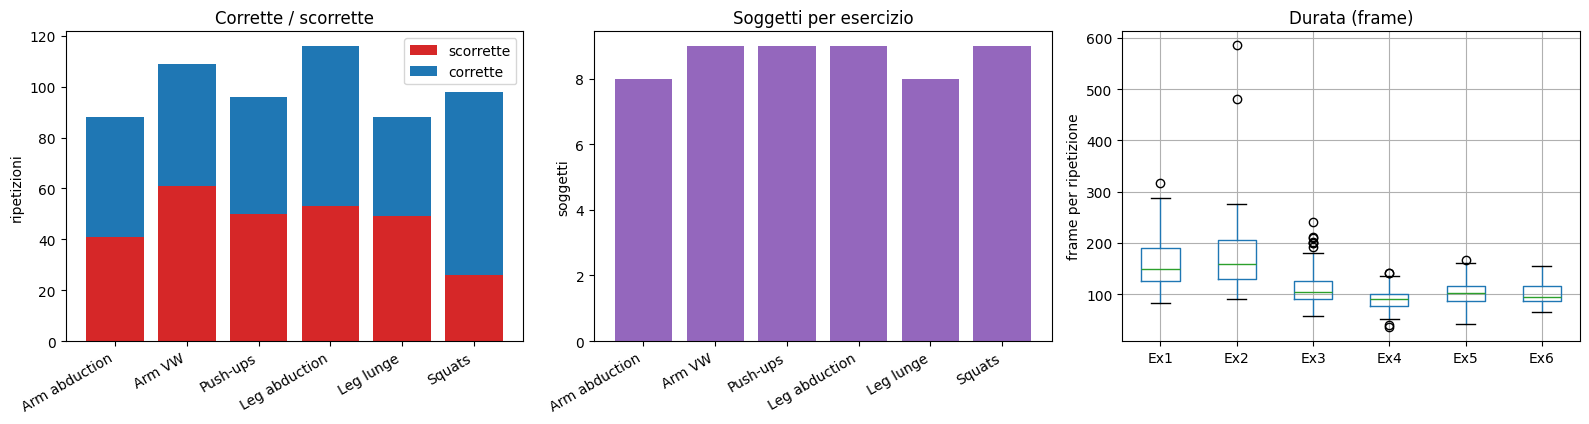

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

x = np.arange(len(EXERCISES))
axes[0].bar(x, summary["scorrette"], label="scorrette", color="tab:red")
axes[0].bar(x, summary["corrette"], bottom=summary["scorrette"], label="corrette", color="tab:blue")
axes[0].set_xticks(x); axes[0].set_xticklabels([EXERCISE_LABELS[e] for e in EXERCISES], rotation=30, ha="right")
axes[0].set_ylabel("ripetizioni"); axes[0].set_title("Corrette / scorrette"); axes[0].legend()

axes[1].bar(x, summary["soggetti"], color="tab:purple")
axes[1].set_xticks(x); axes[1].set_xticklabels([EXERCISE_LABELS[e] for e in EXERCISES], rotation=30, ha="right")
axes[1].set_ylabel("soggetti"); axes[1].set_title("Soggetti per esercizio")

meta.boxplot(column="n_frames", by="exercise", ax=axes[2])
axes[2].set_title("Durata (frame)"); axes[2].set_xlabel(""); axes[2].set_ylabel("frame per ripetizione")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 2. Lo scheletro nei 6 esercizi

Sanity check visivo della mappa dei 26 giunti su ogni tipo di movimento, non solo uno.

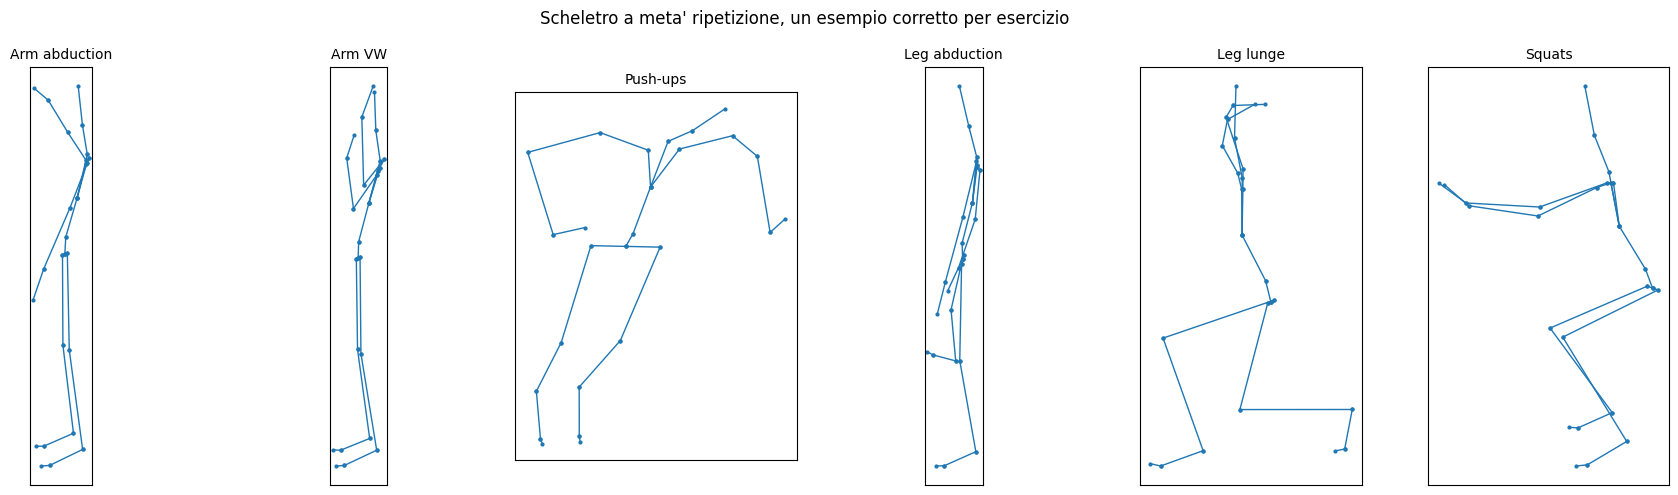

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(18, 5))
for ax, ex in zip(axes, EXERCISES):
    ex_dir = BASE / f"{ex}-segmented"
    example_file = next(ex_dir.glob("*rep1-1.npy"))
    arr = np.load(example_file)
    frame = arr[len(arr) // 2]
    for a, b in BONES:
        ax.plot([frame[a, 0], frame[b, 0]], [frame[a, 1], frame[b, 1]], "o-", color="tab:blue", markersize=2, linewidth=1)
    ax.invert_yaxis(); ax.set_aspect("equal"); ax.set_title(EXERCISE_LABELS[ex], fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Scheletro a meta' ripetizione, un esempio corretto per esercizio")
plt.tight_layout()
plt.show()

## 3. L'angolo giusto per ogni esercizio: corretto vs scorretto

Non lo stesso angolo per tutti - quello anatomicamente piu' rilevante per ciascun movimento, a riprova che il segnale si vede gia' prima di qualsiasi modello.

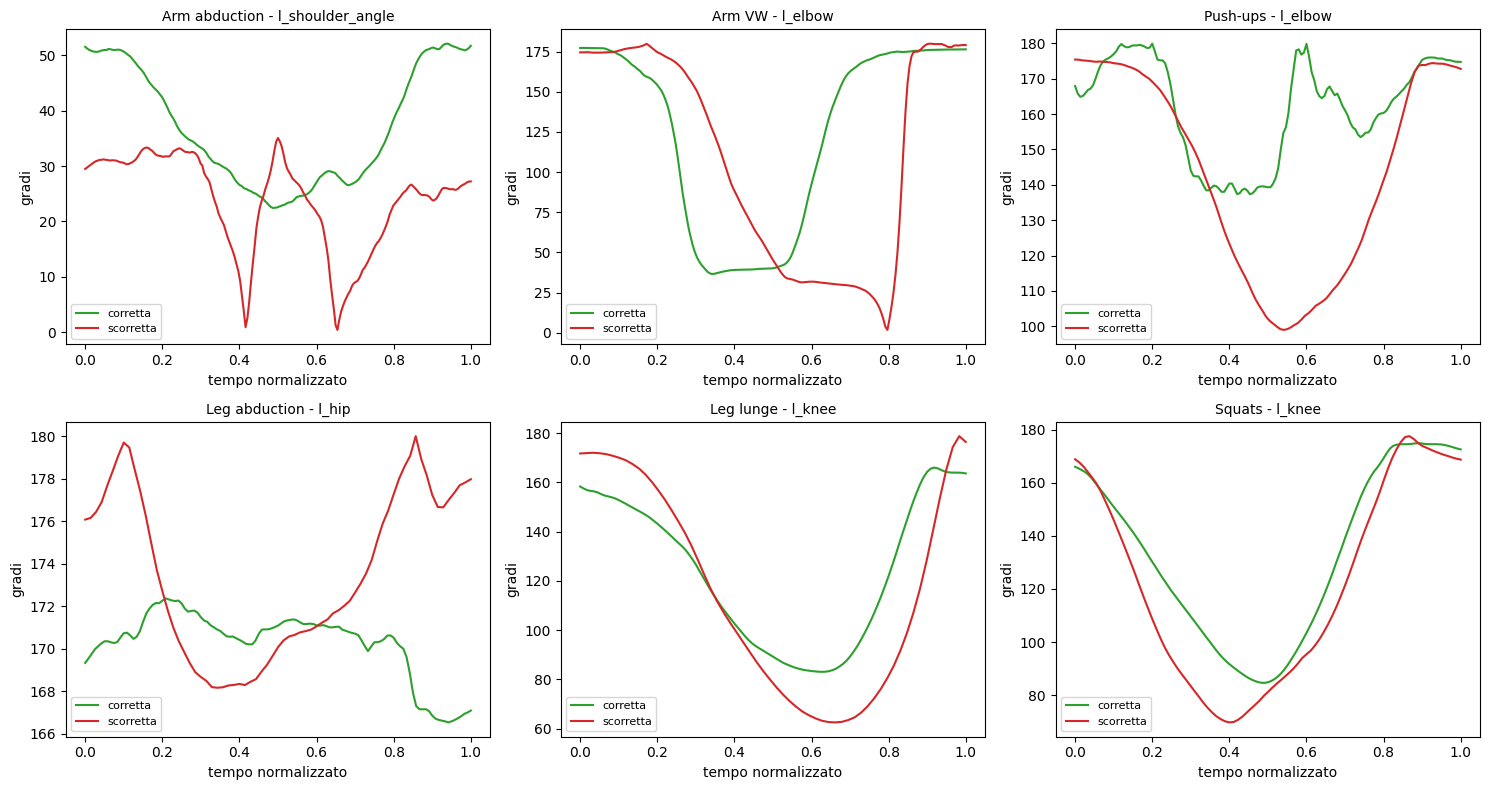

In [5]:
RELEVANT_ANGLE = {
    "Ex1": ("l_shoulder_angle", (3, 6, 7)),   # arm abduction -> shoulder
    "Ex2": ("l_elbow", (7, 8, 9)),             # arm VW -> elbow
    "Ex3": ("l_elbow", (7, 8, 9)),             # push-ups -> elbow
    "Ex4": ("l_hip", (2, 16, 17)),             # leg abduction -> hip
    "Ex5": ("l_knee", (16, 17, 18)),           # lunge -> knee
    "Ex6": ("l_knee", (16, 17, 18)),           # squat -> knee
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, ex in zip(axes.ravel(), EXERCISES):
    ex_dir = BASE / f"{ex}-segmented"
    name, (a, b, c) = RELEVANT_ANGLE[ex]
    files = list(ex_dir.glob("*.npy"))
    correct_file = next((f for f in files if f.name.endswith("-1.npy")), None)
    incorrect_file = next((f for f in files if f.name.endswith("-0.npy")), None)
    for f, label, color in [(correct_file, "corretta", "tab:green"), (incorrect_file, "scorretta", "tab:red")]:
        if f is None:
            continue
        arr = np.load(f)
        signal = angle_series(arr, a, b, c)
        t = np.linspace(0, 1, len(signal))
        ax.plot(t, signal, label=label, color=color)
    ax.set_title(f"{EXERCISE_LABELS[ex]} - {name}", fontsize=10)
    ax.set_xlabel("tempo normalizzato"); ax.set_ylabel("gradi")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Mappa dell'effetto: quale feature conta, per quale esercizio

Correlazione di Spearman (valore assoluto) tra ogni feature anatomica e corretto/scorretto, per ciascuno dei 6 esercizi.

C:\Users\clauc\AppData\Local\Temp\ipykernel_37368\3716097696.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(df.loc[mask, feat], df.loc[mask, "correct"])
C:\Users\clauc\AppData\Local\Temp\ipykernel_37368\3716097696.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(df.loc[mask, feat], df.loc[mask, "correct"])


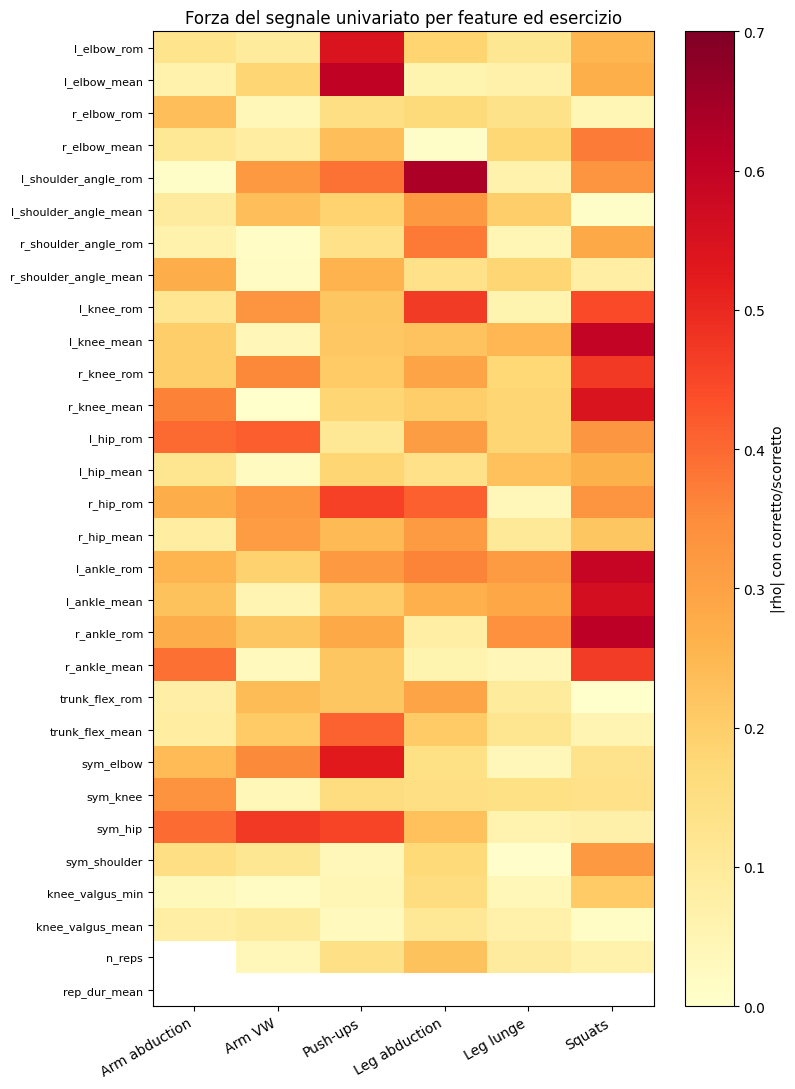

In [6]:
CORE_FEATURES = []
for joint in ["l_elbow", "r_elbow", "l_shoulder_angle", "r_shoulder_angle", "l_knee", "r_knee",
              "l_hip", "r_hip", "l_ankle", "r_ankle", "trunk_flex"]:
    CORE_FEATURES += [f"{joint}_rom", f"{joint}_mean"]
CORE_FEATURES += ["sym_elbow", "sym_knee", "sym_hip", "sym_shoulder",
                   "knee_valgus_min", "knee_valgus_mean", "n_reps", "rep_dur_mean"]

effect_matrix = pd.DataFrame(index=CORE_FEATURES, columns=EXERCISES, dtype=float)
for ex in EXERCISES:
    df = pd.read_csv(f"../data/features_rehab24_{ex.lower()}_anatomical.csv")
    for feat in CORE_FEATURES:
        mask = df[feat].notna()
        if mask.sum() < 3:
            continue
        rho, _ = spearmanr(df.loc[mask, feat], df.loc[mask, "correct"])
        effect_matrix.loc[feat, ex] = abs(rho)

fig, ax = plt.subplots(figsize=(8, 11))
im = ax.imshow(effect_matrix.values.astype(float), aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.7)
ax.set_xticks(range(len(EXERCISES))); ax.set_xticklabels([EXERCISE_LABELS[e] for e in EXERCISES], rotation=30, ha="right")
ax.set_yticks(range(len(CORE_FEATURES))); ax.set_yticklabels(CORE_FEATURES, fontsize=8)
plt.colorbar(im, ax=ax, label="|rho| con corretto/scorretto")
ax.set_title("Forza del segnale univariato per feature ed esercizio")
plt.tight_layout()
plt.show()

## 5. Le classi si separano gia' in 2D? (PCA sulla forma della traiettoria)

Non una prova di generalizzazione (questo e' compito della nested CV), ma una vista onesta di quanto le due classi si sovrappongono nello spazio delle feature.

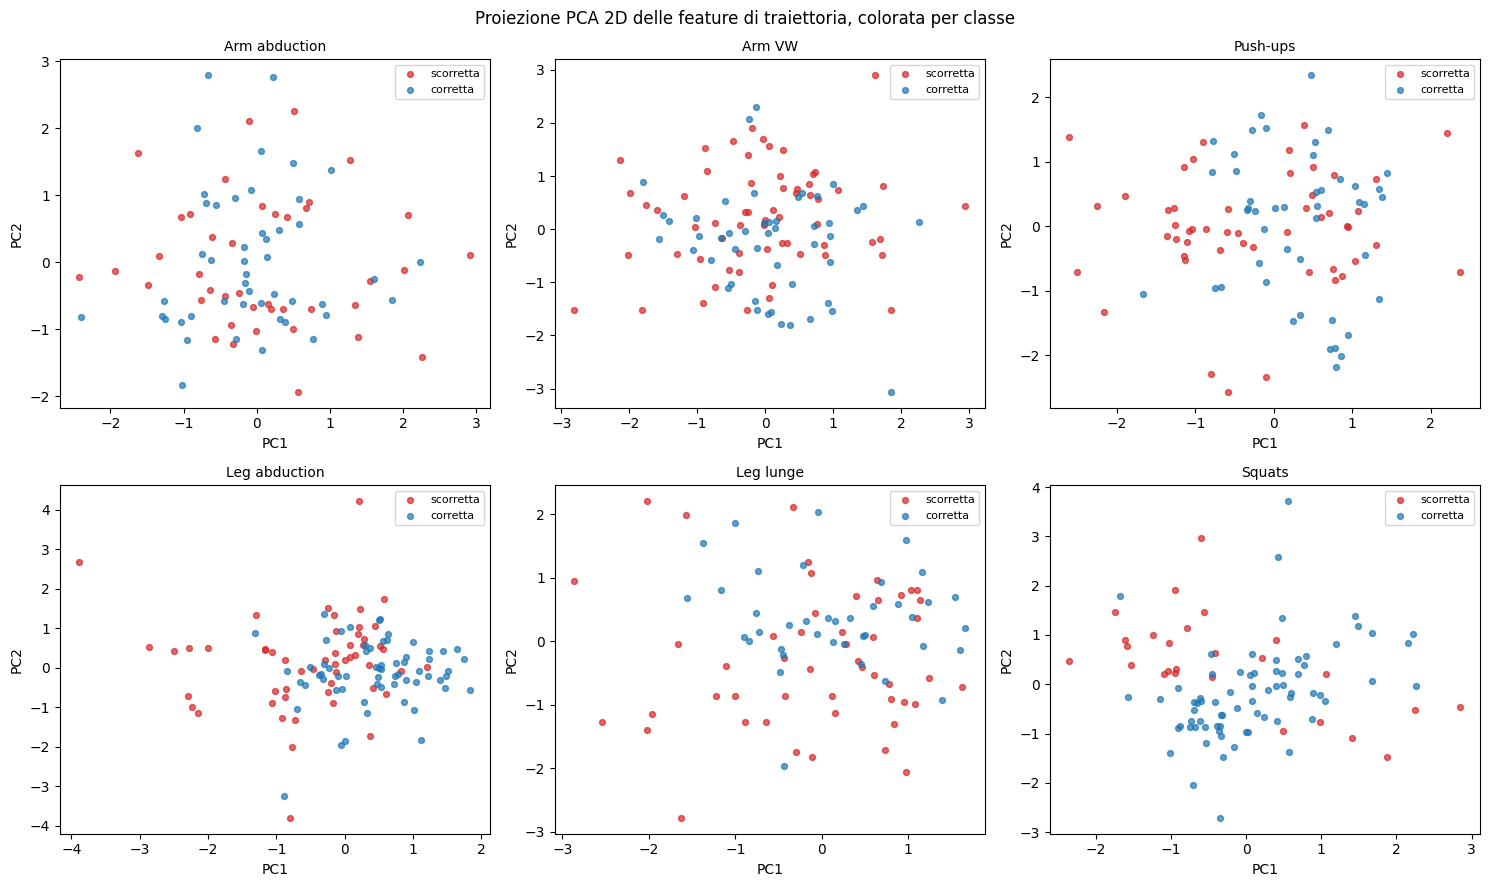

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, ex in zip(axes.ravel(), EXERCISES):
    traj = pd.read_csv(f"../data/features_rehab24_{ex.lower()}.csv")
    feat_cols = [c for c in traj.columns if c.startswith("traj_pc")]
    X = StandardScaler().fit_transform(traj[feat_cols])
    pcs = PCA(n_components=2, random_state=42).fit_transform(X)
    for label, color in [(0, "tab:red"), (1, "tab:blue")]:
        mask = traj["correct"] == label
        ax.scatter(pcs[mask, 0], pcs[mask, 1], s=18, alpha=0.7, color=color,
                   label="corretta" if label else "scorretta")
    ax.set_title(EXERCISE_LABELS[ex], fontsize=10)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8)
plt.suptitle("Proiezione PCA 2D delle feature di traiettoria, colorata per classe")
plt.tight_layout()
plt.show()

## 6. Variabilita' tra soggetti

Se un soggetto ha un range di movimento sistematicamente diverso dagli altri, la CV per soggetto e' ancora piu' importante di quanto sembri - il modello deve generalizzare oltre lo stile personale, non solo oltre la singola ripetizione.

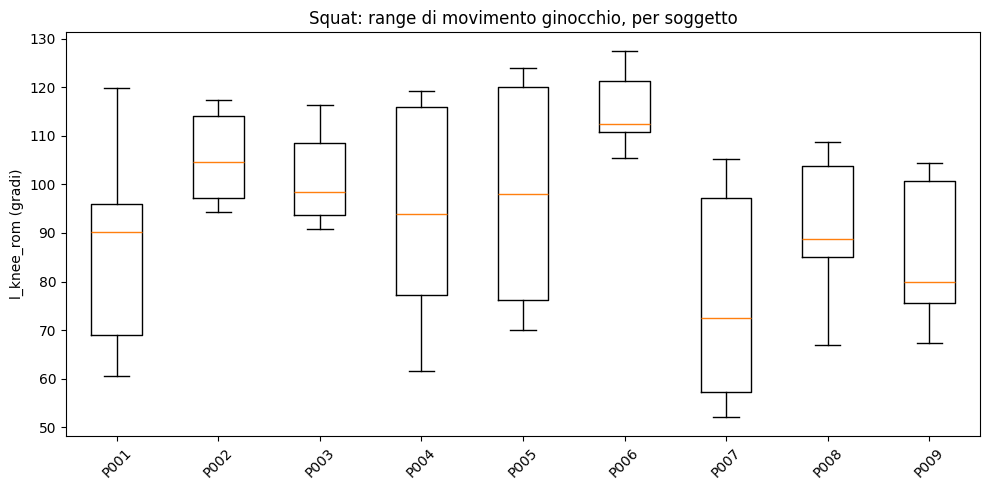

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ex6 = pd.read_csv("../data/features_rehab24_ex6_anatomical.csv")
subjects = sorted(ex6["subject"].unique())
data = [ex6[ex6["subject"] == s]["l_knee_rom"].dropna() for s in subjects]
ax.boxplot(data, tick_labels=subjects)
ax.set_ylabel("l_knee_rom (gradi)")
ax.set_title("Squat: range di movimento ginocchio, per soggetto")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Qualita' del dato: valori mancanti

In [9]:
missing_rows = []
for ex in EXERCISES:
    df = pd.read_csv(f"../data/features_rehab24_{ex.lower()}_anatomical.csv")
    missing_by_col = df.isna().sum()
    missing_cols = missing_by_col[missing_by_col > 0]
    missing_rows.append({"esercizio": ex, "righe": df.shape[0],
                          "colonne_con_mancanti": len(missing_cols),
                          "totale_valori_mancanti": int(missing_by_col.sum()),
                          "colonne": ", ".join(missing_cols.index) if len(missing_cols) else "-"})
print(pd.DataFrame(missing_rows).to_string(index=False))

esercizio  righe  colonne_con_mancanti  totale_valori_mancanti                   colonne
      Ex1     88                     2                     176 rep_dur_mean, rep_dur_std
      Ex2    109                     2                     216 rep_dur_mean, rep_dur_std
      Ex3     96                     2                     192 rep_dur_mean, rep_dur_std
      Ex4    116                     2                     218 rep_dur_mean, rep_dur_std
      Ex5     88                     2                     174 rep_dur_mean, rep_dur_std
      Ex6     98                     2                     194 rep_dur_mean, rep_dur_std


## Conclusioni operative

- La mappa dei 26 giunti e' confermata su tutti e 6 gli esercizi (scheletri coerenti).
- Il pattern atteso (flessione/estensione) e' visibile a occhio in ogni esercizio, con una separazione gia' percepibile tra corretto e scorretto nell'angolo piu' rilevante.
- La mappa dell'effetto mostra che il segnale non e' uniforme: alcune combinazioni feature-esercizio sono molto piu' forti di altre.
- Nella proiezione PCA le classi si sovrappongono parzialmente ma non completamente in quasi tutti gli esercizi - coerente con un segnale reale ma non perfettamente separabile.
- La variabilita' tra soggetti e' non trascurabile - conferma che lo split per soggetto nella nested CV non e' un dettaglio tecnico ma una necessita' reale.